# Weather Forecasting with Time-Series Analysis and Deep Learning

## Overview

This project develops a **daily rainfall forecasting pipeline** using historical hourly weather observations for Colombo, Sri Lanka.

The workflow combines classical time-series diagnostics with recurrent neural networks:

- Exploratory Data Analysis (EDA)
- Hourly-to-daily temporal aggregation
- Outlier investigation
- Stationarity analysis using the Augmented Dickey-Fuller (ADF) test
- ACF and PACF analysis
- Ljung-Box residual/autocorrelation diagnostics
- Time-series feature engineering
- Chronological train/validation/test splitting
- Min-Max scaling without data leakage
- 14-day look-back sequences
- SimpleRNN and LSTM models
- Hyperparameter tuning using the validation set
- Early stopping and learning-rate reduction
- Evaluation using MAE, RMSE and R²
- Climatology and persistence baselines
- Residual/error analysis
- Model comparison and export of predictions

### Research question

> **How accurately can daily rainfall be forecast one day ahead using recent rainfall history and meteorological variables?**

### Important forecasting definition

The target is **next-day total rainfall (mm)**.

The model uses the previous 14 days of information to predict rainfall for the following day. This is a one-step-ahead forecasting problem, rather than a claim of producing a reliable 14-day future weather forecast.

## Dataset

The source file contains hourly observations from **1 January 2014 to 31 July 2026**.

The raw dataset contains:

- Temperature
- Relative humidity
- Rainfall
- Wind speed at 10 m and 100 m
- Wind direction at 10 m and 100 m
- Wind gusts
- Precipitation
- Apparent temperature
- Mean sea-level pressure

The hourly observations are aggregated into daily observations before modelling.

In [1]:
# ============================================================
# 1. Import libraries and set reproducibility
# ============================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
import random
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.21.0
NumPy: 2.4.6
Pandas: 3.0.5


## 2. Load and inspect the raw hourly data

In [2]:
# ============================================================
# 2. Load the Excel dataset
# ============================================================

DATA_PATH = "weather_raw.xlsx"

location_info = pd.read_excel(DATA_PATH, header=None, nrows=2)
df = pd.read_excel(DATA_PATH, header=3)

df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time").sort_index()

print("Location information:")
display(location_info)

print(f"Hourly observations: {len(df):,}")
print("Date range:", df.index.min(), "to", df.index.max())

display(df.head())

Location information:


,0,1,2,3,4,5
0,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
1,6.9244,79.9073,9,0,GMT,GMT


Hourly observations: 110,280
Date range: 2014-01-01 00:00:00 to 2026-07-31 23:00:00


,temperature_2m (°C),relative_humidity_2m (%),rain (mm),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_gusts_10m (km/h),precipitation (mm),apparent_temperature (°C),pressure_msl (hPa)
time,,,,,,,,,,,
2014-01-01 00:00:00,23.6,84,0.0,16.1,27.9,10,15,31.3,0.0,25.4,1010.6
2014-01-01 01:00:00,23.5,85,0.0,16.2,28.1,12,16,31.7,0.0,25.4,1011.1
2014-01-01 02:00:00,24.2,82,0.0,16.6,26.3,13,17,32.8,0.0,26.1,1012.2
2014-01-01 03:00:00,25.4,77,0.0,17.5,25.1,19,21,36.7,0.0,27.2,1012.4
2014-01-01 04:00:00,26.8,70,0.0,17.9,24.3,28,29,38.9,0.0,28.5,1012.9


In [3]:
# ============================================================
# 3. Raw data quality checks
# ============================================================

print("Shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate timestamps:", df.index.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe().T.round(2))

Shape: (110280, 11)

Data types:


,dtype
temperature_2m (°C),float64
relative_humidity_2m (%),int64
rain (mm),float64
wind_speed_10m (km/h),float64
wind_speed_100m (km/h),float64
wind_direction_10m (°),int64
wind_direction_100m (°),int64
wind_gusts_10m (km/h),float64
precipitation (mm),float64
apparent_temperature (°C),float64



Missing values:


,missing_values
temperature_2m (°C),0
relative_humidity_2m (%),0
rain (mm),0
wind_speed_10m (km/h),0
wind_speed_100m (km/h),0
wind_direction_10m (°),0
wind_direction_100m (°),0
wind_gusts_10m (km/h),0
precipitation (mm),0
apparent_temperature (°C),0



Duplicate timestamps: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
temperature_2m (°C),110280.0,26.72,2.11,18.2,25.2,26.5,28.1,35.8
relative_humidity_2m (%),110280.0,83.12,10.56,27.0,78.0,85.0,91.0,100.0
rain (mm),110280.0,0.32,0.94,0.0,0.0,0.0,0.2,38.9
wind_speed_10m (km/h),110280.0,10.08,5.28,0.0,5.8,9.4,13.8,41.9
wind_speed_100m (km/h),110280.0,15.77,7.56,0.0,10.0,15.5,21.0,64.9
wind_direction_10m (°),110280.0,186.12,90.03,0.0,126.0,216.0,248.0,360.0
wind_direction_100m (°),110280.0,189.15,89.79,0.0,143.0,219.0,249.0,360.0
wind_gusts_10m (km/h),110280.0,23.36,11.20,0.7,14.4,22.3,31.3,82.1
precipitation (mm),110280.0,0.32,0.94,0.0,0.0,0.0,0.2,38.9
apparent_temperature (°C),110280.0,31.24,2.57,18.9,29.7,31.1,32.7,41.1


In [4]:
# ============================================================
# 4. Check hourly timestamp continuity
# ============================================================

expected_hours = pd.date_range(
    df.index.min(),
    df.index.max(),
    freq="h"
)

missing_timestamps = expected_hours.difference(df.index)

print("Expected hourly timestamps:", len(expected_hours))
print("Observed timestamps:       ", len(df))
print("Missing hourly timestamps: ", len(missing_timestamps))

if len(missing_timestamps) == 0:
    print("✓ Hourly time series is continuous.")
else:
    print("⚠ Missing hourly timestamps detected.")
    display(pd.DataFrame({"missing_timestamp": missing_timestamps[:20]}))

Expected hourly timestamps: 110280
Observed timestamps:        110280
Missing hourly timestamps:  0
✓ Hourly time series is continuous.


## 3. Convert hourly observations to daily observations

Rainfall is aggregated using **sum**, because daily rainfall represents the total accumulated rainfall.

Temperature uses mean/min/max, while humidity, wind speed and pressure use daily means.

In [5]:
# ============================================================
# 5. Hourly → daily aggregation
# ============================================================

daily = pd.DataFrame(index=df.resample("D").size().index)

daily["rain_sum"] = df["rain (mm)"].resample("D").sum()
daily["temp_mean"] = df["temperature_2m (°C)"].resample("D").mean()
daily["temp_max"] = df["temperature_2m (°C)"].resample("D").max()
daily["temp_min"] = df["temperature_2m (°C)"].resample("D").min()
daily["humidity_mean"] = df["relative_humidity_2m (%)"].resample("D").mean()
daily["wind_speed_mean"] = df["wind_speed_10m (km/h)"].resample("D").mean()
daily["wind_speed_100m_mean"] = df["wind_speed_100m (km/h)"].resample("D").mean()
daily["wind_gust_max"] = df["wind_gusts_10m (km/h)"].resample("D").max()
daily["pressure_mean"] = df["pressure_msl (hPa)"].resample("D").mean()
daily["apparent_temp_mean"] = df["apparent_temperature (°C)"].resample("D").mean()

print("Daily dataset shape:", daily.shape)
display(daily.head())

Daily dataset shape: (4595, 10)


,rain_sum,temp_mean,temp_max,temp_min,humidity_mean,wind_speed_mean,wind_speed_100m_mean,wind_gust_max,pressure_mean,apparent_temp_mean
time,,,,,,,,,,
2014-01-01,0.0,26.808333,31.3,23.4,65.375000,16.691667,25.945833,39.6,1010.750000,28.133333
2014-01-02,0.0,26.600000,31.0,23.2,67.916667,15.312500,23.562500,41.4,1011.400000,28.362500
2014-01-03,0.0,26.379167,30.3,23.4,72.416667,14.891667,22.600000,42.8,1011.841667,28.608333
2014-01-04,0.0,25.620833,29.4,22.4,68.416667,16.904167,25.225000,43.6,1010.950000,26.641667
2014-01-05,0.0,25.245833,29.0,22.4,73.666667,11.841667,17.366667,41.0,1010.029167,27.487500


In [6]:
# ============================================================
# 6. Daily data quality checks
# ============================================================

print("Missing values after aggregation:")
display(daily.isna().sum().to_frame("missing_values"))

print("\nDaily descriptive statistics:")
display(daily.describe().T.round(2))

Missing values after aggregation:


,missing_values
rain_sum,0
temp_mean,0
temp_max,0
temp_min,0
humidity_mean,0
wind_speed_mean,0
wind_speed_100m_mean,0
wind_gust_max,0
pressure_mean,0
apparent_temp_mean,0



Daily descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
rain_sum,4595.0,7.65,11.33,0.00,1.10,3.70,10.20,261.80
temp_mean,4595.0,26.72,1.00,23.50,26.01,26.69,27.38,30.00
temp_max,4595.0,29.67,1.59,24.50,28.60,29.40,30.60,35.80
temp_min,4595.0,24.25,1.27,18.20,23.40,24.40,25.10,28.10
humidity_mean,4595.0,83.12,6.53,49.96,80.38,84.79,87.71,95.21
wind_speed_mean,4595.0,10.08,4.03,2.42,6.81,9.57,12.68,30.08
wind_speed_100m_mean,4595.0,15.77,6.28,3.27,10.50,15.29,20.12,47.62
wind_gust_max,4595.0,36.76,8.63,13.00,30.60,36.40,42.10,82.10
pressure_mean,4595.0,1009.93,1.48,1004.01,1008.95,1009.93,1010.95,1015.13
apparent_temp_mean,4595.0,31.24,1.50,25.03,30.38,31.25,32.19,35.82


## 4. Outlier investigation

For weather data, an IQR outlier is **not automatically an error**.

For example, a very high rainfall day may be a genuine extreme weather event. Therefore:

- We identify potential outliers.
- We visualize them.
- We do **not** blindly cap rainfall.
- We retain genuine extreme rainfall observations because they are important for the forecasting problem.

In [7]:
# ============================================================
# 7. IQR-based outlier screening
# ============================================================

numeric_cols = daily.select_dtypes(include=np.number).columns.tolist()

outlier_summary = []

for col in numeric_cols:
    q1 = daily[col].quantile(0.25)
    q3 = daily[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((daily[col] < lower) | (daily[col] > upper)).sum()

    outlier_summary.append({
        "Variable": col,
        "Lower bound": lower,
        "Upper bound": upper,
        "Potential outliers": count
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary.round(2))

,Variable,Lower bound,Upper bound,Potential outliers
0,rain_sum,-12.55,23.85,331
1,temp_mean,23.96,29.42,30
2,temp_max,25.60,33.60,92
3,temp_min,20.85,27.65,67
4,humidity_mean,69.38,98.71,228
5,wind_speed_mean,-1.99,21.48,36
6,wind_speed_100m_mean,-3.93,34.55,22
7,wind_gust_max,13.35,59.35,50
8,pressure_mean,1005.95,1013.94,43
9,apparent_temp_mean,27.66,34.91,114


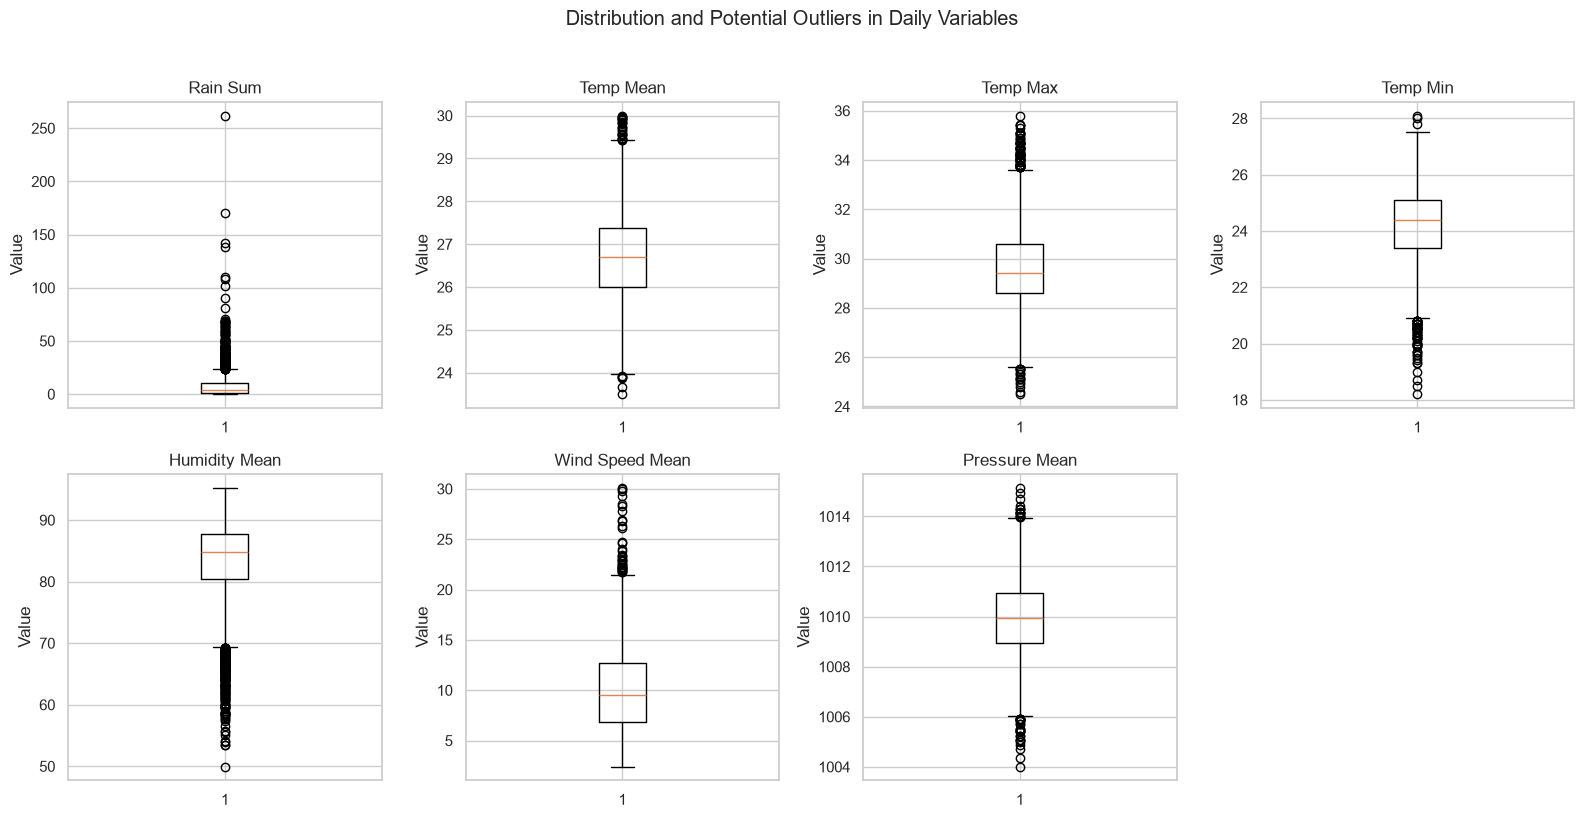

In [8]:
# ============================================================
# 8. Boxplots for potential outliers
# ============================================================

plot_cols = [
    "rain_sum",
    "temp_mean",
    "temp_max",
    "temp_min",
    "humidity_mean",
    "wind_speed_mean",
    "pressure_mean"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    ax.boxplot(daily[col].dropna())
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("Value")

axes[-1].axis("off")
plt.suptitle("Distribution and Potential Outliers in Daily Variables", y=1.02)
plt.tight_layout()
plt.show()

### Outlier decision

No automatic winsorization is applied. The original notebook capped temperature and pressure using IQR bounds, but this can distort real meteorological extremes. The revised approach treats IQR results as a **screening diagnostic**, not proof that an observation is invalid.

The rainfall maximum in the dataset is approximately **261.8 mm/day**, which should be retained unless an independent data-quality check shows that it is erroneous.

## 5. Exploratory Data Analysis

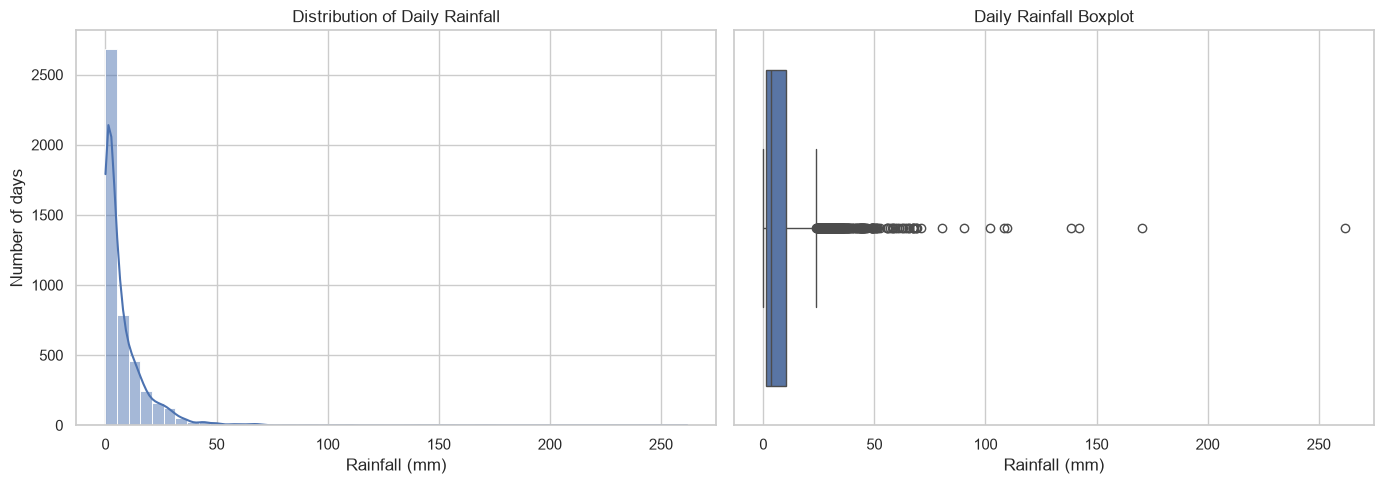

In [9]:
# ============================================================
# 9. Daily rainfall distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(daily["rain_sum"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Daily Rainfall")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Number of days")

sns.boxplot(x=daily["rain_sum"], ax=axes[1])
axes[1].set_title("Daily Rainfall Boxplot")
axes[1].set_xlabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

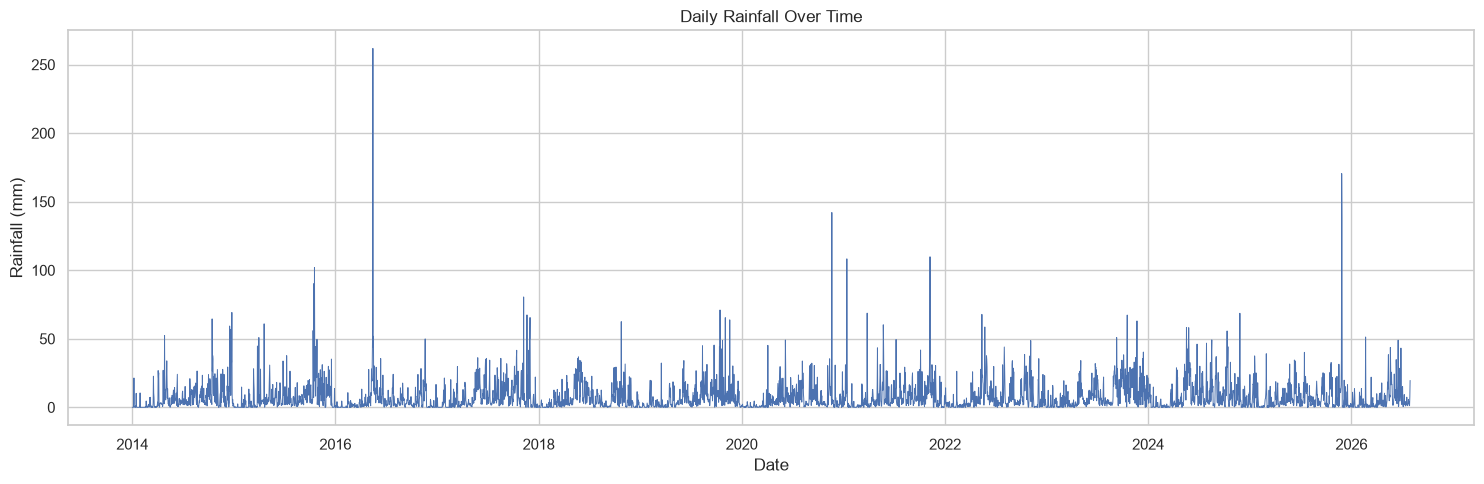

In [10]:
# ============================================================
# 10. Rainfall time-series trend
# ============================================================

plt.figure(figsize=(15, 5))
plt.plot(daily.index, daily["rain_sum"], linewidth=0.7)
plt.title("Daily Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

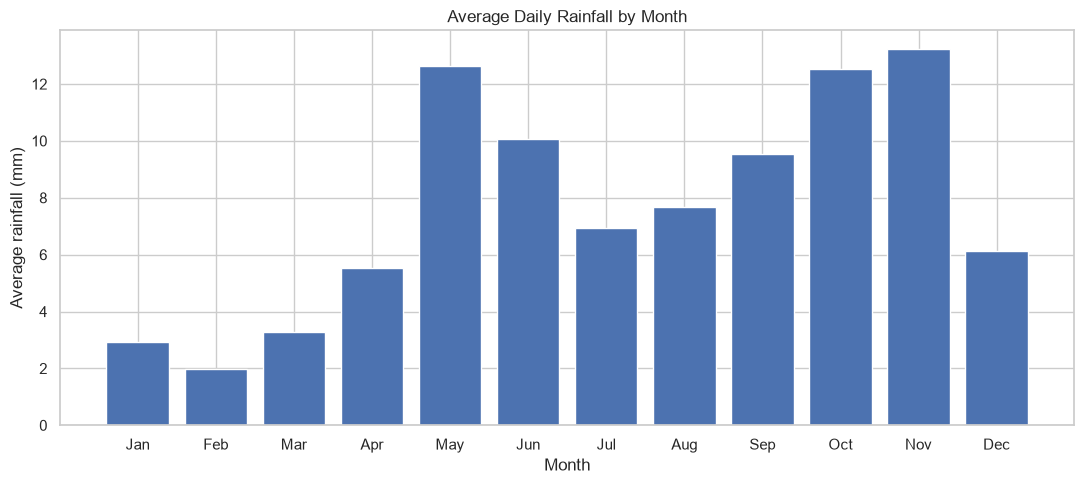

In [11]:
# ============================================================
# 11. Monthly rainfall seasonality
# ============================================================

monthly_rain = daily.groupby(daily.index.month)["rain_sum"].mean()

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(11, 5))
plt.bar(month_labels, monthly_rain.values)
plt.title("Average Daily Rainfall by Month")
plt.xlabel("Month")
plt.ylabel("Average rainfall (mm)")
plt.tight_layout()
plt.show()

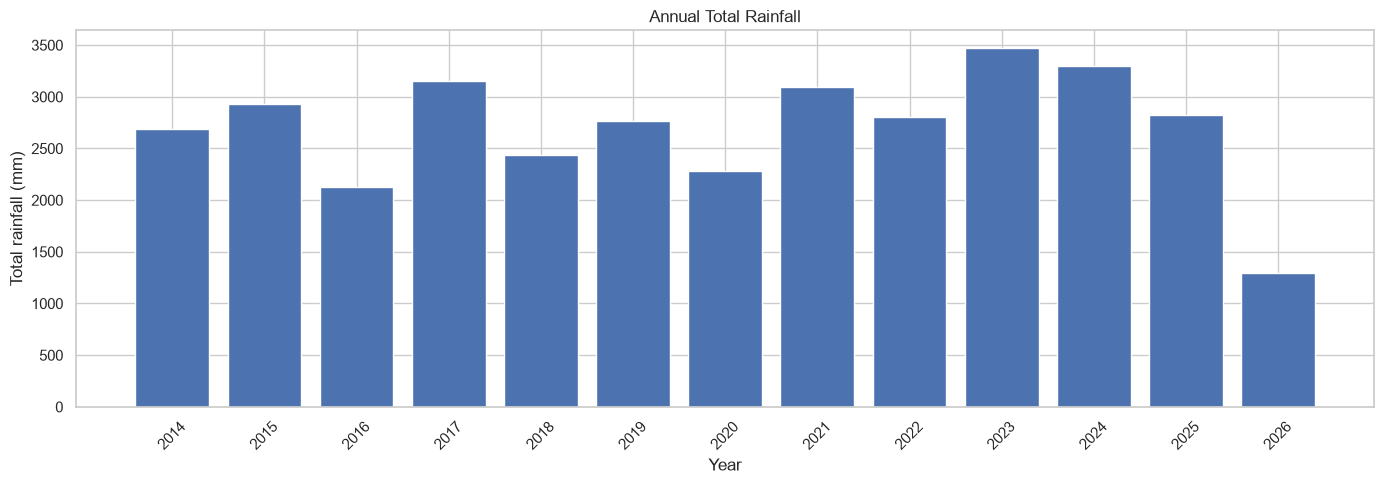

In [12]:
# ============================================================
# 12. Annual rainfall summary
# ============================================================

annual_rain = daily["rain_sum"].resample("YE").sum()

plt.figure(figsize=(14, 5))
plt.bar(annual_rain.index.year.astype(str), annual_rain.values)
plt.title("Annual Total Rainfall")
plt.xlabel("Year")
plt.ylabel("Total rainfall (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

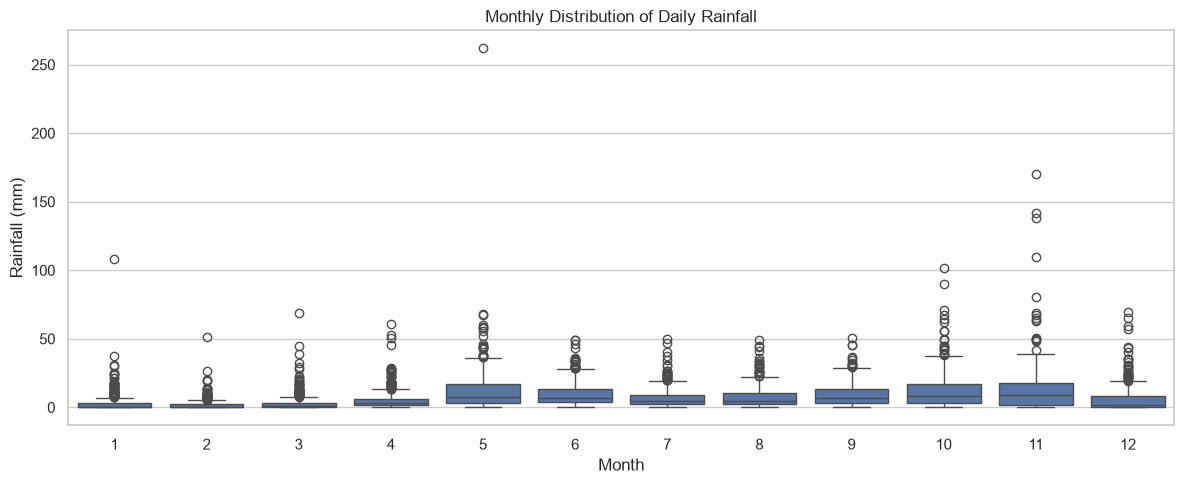

In [13]:
# ============================================================
# 13. Monthly rainfall distribution
# ============================================================

monthly_box = daily.copy()
monthly_box["month"] = monthly_box.index.month

plt.figure(figsize=(12, 5))
sns.boxplot(data=monthly_box, x="month", y="rain_sum")
plt.title("Monthly Distribution of Daily Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

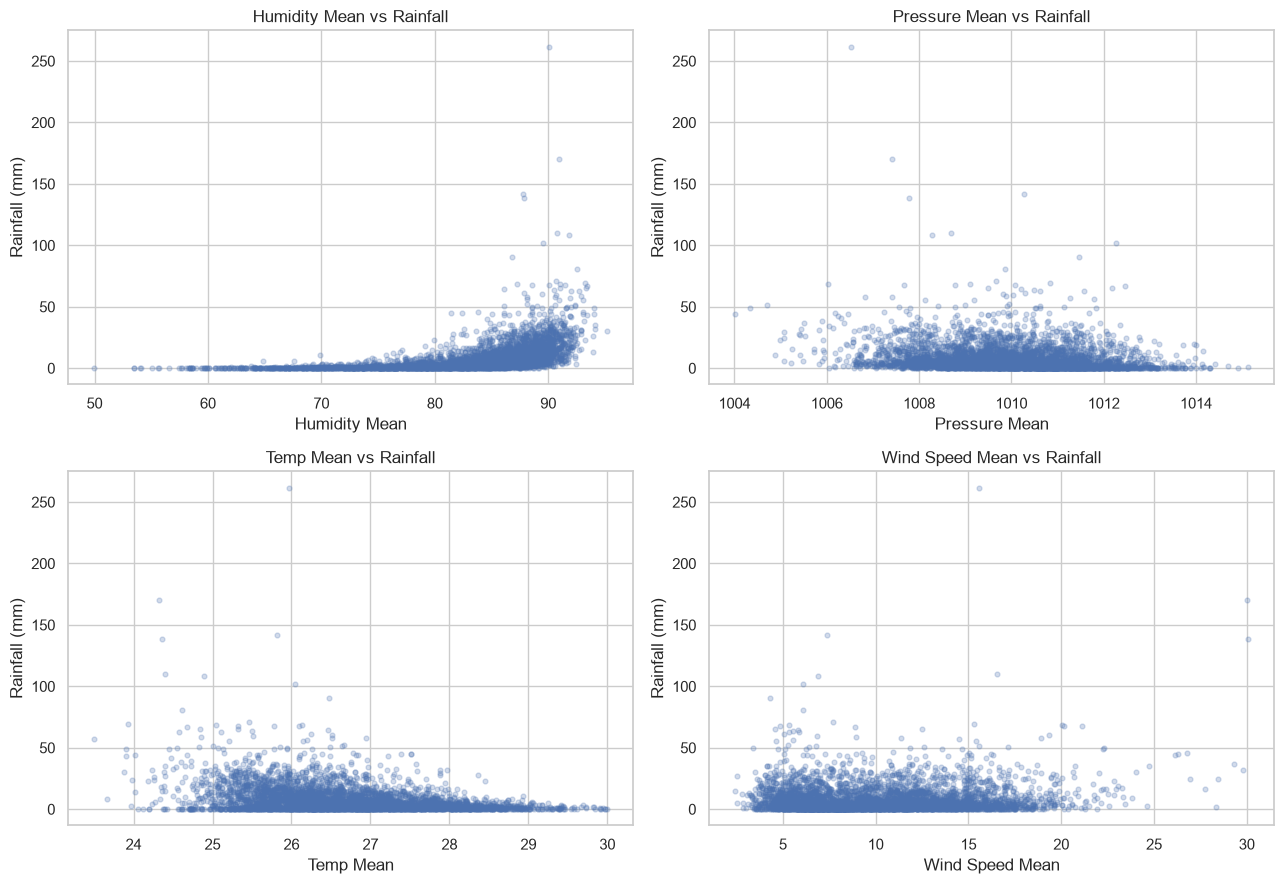

In [14]:
# ============================================================
# 14. Weather variables vs rainfall
# ============================================================

relationships = [
    "humidity_mean",
    "pressure_mean",
    "temp_mean",
    "wind_speed_mean"
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.ravel(), relationships):
    ax.scatter(
        daily[col],
        daily["rain_sum"],
        alpha=0.25,
        s=12
    )
    ax.set_title(
        f"{col.replace('_', ' ').title()} vs Rainfall"
    )
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

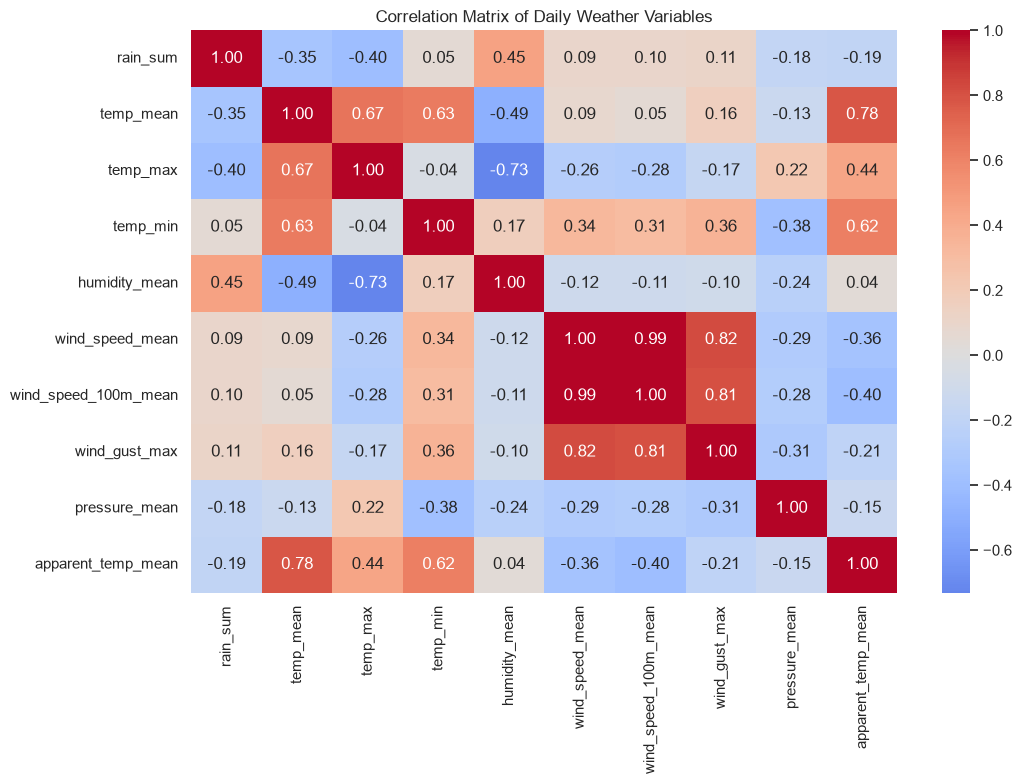

In [15]:
# ============================================================
# 15. Correlation matrix
# ============================================================

corr_cols = [
    "rain_sum",
    "temp_mean",
    "temp_max",
    "temp_min",
    "humidity_mean",
    "wind_speed_mean",
    "wind_speed_100m_mean",
    "wind_gust_max",
    "pressure_mean",
    "apparent_temp_mean"
]

plt.figure(figsize=(11, 8))
sns.heatmap(
    daily[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Daily Weather Variables")
plt.tight_layout()
plt.show()

## 6. Time-series diagnostics

Before applying recurrent models, it is useful to understand the statistical behaviour of the rainfall series.

We examine:

- Stationarity using the ADF test
- Autocorrelation using ACF
- Partial autocorrelation using PACF
- Ljung-Box test for serial dependence

These diagnostics support the use of lagged time-series information and help explain the temporal structure of the target.

In [16]:
# ============================================================
# 16. Augmented Dickey-Fuller test
# ============================================================

rain_series = daily["rain_sum"]

adf_result = adfuller(rain_series, autolag="AIC")

adf_table = pd.DataFrame({
    "Statistic": [adf_result[0]],
    "p-value": [adf_result[1]],
    "Used lags": [adf_result[2]],
    "Observations": [adf_result[3]]
})

display(adf_table.round(4))

print("Critical values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusion: Reject H0. The rainfall series is stationary according to the ADF test.")
else:
    print("\nConclusion: Fail to reject H0. Evidence of non-stationarity remains.")

,Statistic,p-value,Used lags,Observations
0,-10.6838,0.0,18,4576


Critical values:
  1%: -3.4318
  5%: -2.8622
  10%: -2.5671

Conclusion: Reject H0. The rainfall series is stationary according to the ADF test.


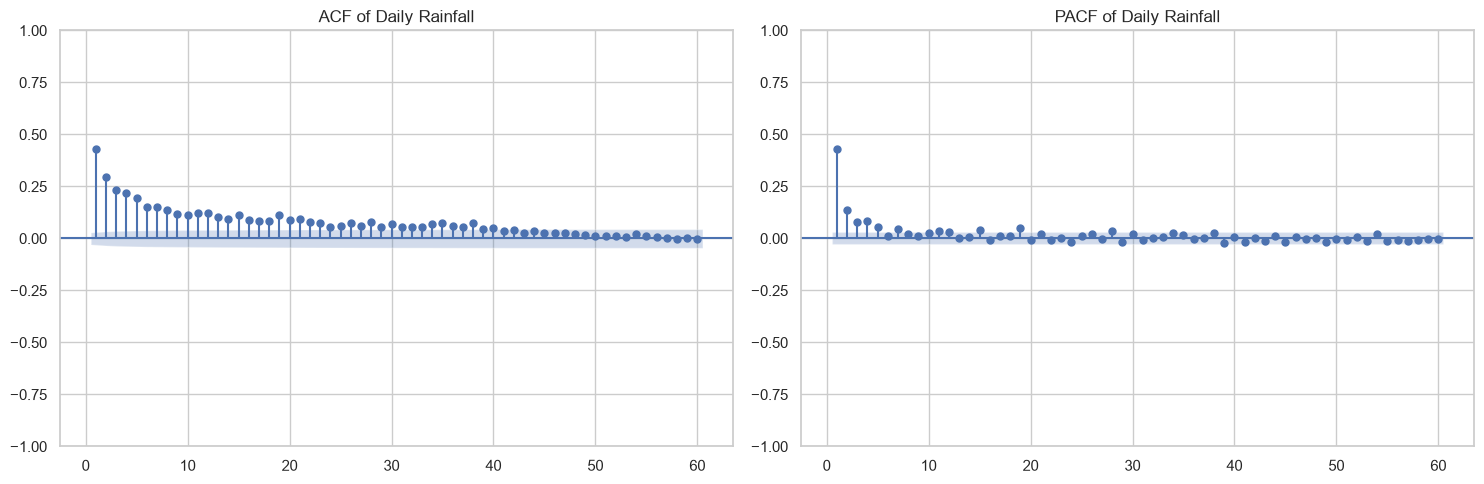

In [17]:
# ============================================================
# 17. ACF and PACF of rainfall
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(
    rain_series,
    lags=60,
    ax=axes[0],
    zero=False
)
axes[0].set_title("ACF of Daily Rainfall")

plot_pacf(
    rain_series,
    lags=60,
    ax=axes[1],
    zero=False,
    method="ywm"
)
axes[1].set_title("PACF of Daily Rainfall")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 18. Ljung-Box test
# ============================================================

ljung_box = acorr_ljungbox(
    rain_series,
    lags=[7, 14, 30],
    return_df=True
)

display(ljung_box)

print(
    "\nInterpretation: a p-value below 0.05 indicates evidence "
    "of serial autocorrelation at that lag."
)

,lb_stat,lb_pvalue
7,2107.672549,0.0
14,2536.284240,0.0
30,3019.695438,0.0



Interpretation: a p-value below 0.05 indicates evidence of serial autocorrelation at that lag.


## 7. Feature engineering

The neural networks receive a sequence containing information from the previous 14 days.

Features include:

### Rainfall history
- 1-day lag
- 2-day lag
- 3-day lag
- 7-day lag
- 14-day lag
- 3-day rolling mean
- 7-day rolling mean
- 14-day rolling mean

### Meteorological variables
- temperature
- humidity
- wind speed
- wind gust
- pressure
- apparent temperature

### Seasonality
- sine/cosine day-of-year features

### Important leakage prevention

All rainfall rolling features are shifted by one day before the rolling calculation. Therefore, the target day's rainfall is never used to construct its own predictors.

In [19]:
# ============================================================
# 19. Feature engineering
# ============================================================

data = daily.copy()

# Log transformation for the highly right-skewed rainfall target
data["rain_log"] = np.log1p(data["rain_sum"])

# Lagged rainfall features
for lag in [1, 2, 3, 7, 14]:
    data[f"rain_lag_{lag}"] = data["rain_log"].shift(lag)

# Rolling statistics based ONLY on previous observations
for window in [3, 7, 14]:
    data[f"rain_rolling_mean_{window}"] = (
        data["rain_log"]
        .shift(1)
        .rolling(window)
        .mean()
    )

# Temperature range
data["temp_range"] = data["temp_max"] - data["temp_min"]

# Calendar/seasonality features
day_of_year = data.index.dayofyear

data["sin_day"] = np.sin(
    2 * np.pi * day_of_year / 365.25
)

data["cos_day"] = np.cos(
    2 * np.pi * day_of_year / 365.25
)

data["month"] = data.index.month

# Remove rows made incomplete by lag/rolling features
data = data.dropna().copy()

print("Feature-engineered shape:", data.shape)
display(data.head())

Feature-engineered shape: (4581, 23)


,rain_sum,temp_mean,temp_max,temp_min,humidity_mean,wind_speed_mean,wind_speed_100m_mean,wind_gust_max,pressure_mean,apparent_temp_mean,...,rain_lag_3,rain_lag_7,rain_lag_14,rain_rolling_mean_3,rain_rolling_mean_7,rain_rolling_mean_14,temp_range,sin_day,cos_day,month
time,,,,,,,,,,,,,,,,,,,,,
2014-01-15,10.2,25.775000,29.5,23.2,86.375000,4.858333,7.754167,25.2,1013.216667,30.820833,...,0.693147,0.832909,0.0,0.374977,0.317172,0.474114,6.3,0.255182,0.966893,1
2014-01-16,1.1,26.258333,29.6,23.6,78.750000,6.683333,11.020833,23.8,1013.470833,30.383333,...,0.095310,0.262364,0.0,0.949232,0.543315,0.646679,6.0,0.271777,0.962360,1
2014-01-17,0.0,26.862500,31.1,22.9,70.958333,13.520833,21.508333,34.2,1012.379167,29.441667,...,0.336472,0.000000,0.0,1.164774,0.611826,0.699675,8.2,0.288291,0.957543,1
2014-01-18,0.0,26.654167,31.2,22.5,69.833333,9.808333,15.658333,29.9,1012.758333,29.541667,...,2.415914,0.000000,0.0,1.052617,0.611826,0.699675,8.7,0.304719,0.952442,1
2014-01-19,0.0,26.887500,31.6,22.7,68.083333,10.991667,17.550000,33.5,1013.754167,29.412500,...,0.741937,0.693147,0.0,0.247312,0.611826,0.699675,8.9,0.321058,0.947060,1


In [20]:
# ============================================================
# 20. Feature correlation with target
# ============================================================

feature_corr = (
    data.select_dtypes(include=np.number)
    .corr()["rain_log"]
    .sort_values(ascending=False)
)

display(feature_corr.to_frame("correlation_with_rain_log").round(3))

,correlation_with_rain_log
rain_log,1.000
rain_sum,0.787
humidity_mean,0.692
rain_lag_1,0.642
rain_rolling_mean_3,0.612
rain_rolling_mean_7,0.564
rain_rolling_mean_14,0.521
rain_lag_2,0.498
rain_lag_3,0.429
month,0.319


## 8. Chronological train / validation / test split

Because this is a time-series problem, observations are **not randomly shuffled**.

The split is:

- 80% training
- 10% validation
- 10% testing

The test period remains unseen until final evaluation.

In [21]:
# ============================================================
# 21. Define model features
# ============================================================

FEATURE_COLUMNS = [
    "rain_log",
    "temp_mean",
    "temp_max",
    "temp_min",
    "humidity_mean",
    "wind_speed_mean",
    "wind_speed_100m_mean",
    "wind_gust_max",
    "pressure_mean",
    "apparent_temp_mean",
    "temp_range",
    "rain_lag_1",
    "rain_lag_2",
    "rain_lag_3",
    "rain_lag_7",
    "rain_lag_14",
    "rain_rolling_mean_3",
    "rain_rolling_mean_7",
    "rain_rolling_mean_14",
    "sin_day",
    "cos_day"
]

TARGET_COLUMN = "rain_log"

model_data = data[FEATURE_COLUMNS].copy()

n = len(model_data)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_data = model_data.iloc[:train_end]
val_data = model_data.iloc[train_end:val_end]
test_data = model_data.iloc[val_end:]

print(f"Training:   {len(train_data):,} observations")
print(f"Validation: {len(val_data):,} observations")
print(f"Testing:    {len(test_data):,} observations")

print("\nDate ranges:")
print("Train:", train_data.index.min(), "→", train_data.index.max())
print("Val:  ", val_data.index.min(), "→", val_data.index.max())
print("Test: ", test_data.index.min(), "→", test_data.index.max())

Training:   3,664 observations
Validation: 458 observations
Testing:    459 observations

Date ranges:
Train: 2014-01-15 00:00:00 → 2024-01-26 00:00:00
Val:   2024-01-27 00:00:00 → 2025-04-28 00:00:00
Test:  2025-04-29 00:00:00 → 2026-07-31 00:00:00


## 9. Feature scaling

Min-Max scaling is fitted **only on the training data**.

This is essential because fitting the scaler on the complete dataset would allow information from the future test period to influence the transformation.

In [22]:
# ============================================================
# 22. Fit scaler only on training data
# ============================================================

scaler = MinMaxScaler()

scaler.fit(train_data.values)

scaled_data = scaler.transform(model_data.values)

TARGET_INDEX = FEATURE_COLUMNS.index(TARGET_COLUMN)

print("Scaled data shape:", scaled_data.shape)
print("Target index:", TARGET_INDEX)

Scaled data shape: (4581, 21)
Target index: 0


## 10. Create 14-day sequences

Each sample contains the previous **14 days** of weather information.

For example:

> Days 1–14 → predict rainfall on Day 15

The same logic is applied through the complete chronological dataset.

In [23]:
# ============================================================
# 23. Create supervised sequences
# ============================================================

WINDOW_SIZE = 14

def create_sequences(
    scaled_array,
    target_start,
    target_end,
    window_size,
    target_index
):
    X, y, positions = [], [], []

    for target_position in range(target_start, target_end):
        start_position = target_position - window_size

        X.append(
            scaled_array[start_position:target_position]
        )

        y.append(
            scaled_array[target_position, target_index]
        )

        positions.append(target_position)

    return (
        np.array(X),
        np.array(y),
        np.array(positions)
    )


X_train, y_train, train_positions = create_sequences(
    scaled_data,
    WINDOW_SIZE,
    train_end,
    WINDOW_SIZE,
    TARGET_INDEX
)

X_val, y_val, val_positions = create_sequences(
    scaled_data,
    train_end,
    val_end,
    WINDOW_SIZE,
    TARGET_INDEX
)

X_test, y_test, test_positions = create_sequences(
    scaled_data,
    val_end,
    n,
    WINDOW_SIZE,
    TARGET_INDEX
)

INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("Input shape:", INPUT_SHAPE)

X_train: (3650, 14, 21)
X_val:   (458, 14, 21)
X_test:  (459, 14, 21)
Input shape: (14, 21)


## 11. Baseline models

Deep learning should not be judged in isolation.

Two simple baselines are included:

1. **Climatology baseline:** always predicts the mean rainfall observed in the training period.
2. **Persistence baseline:** predicts tomorrow's rainfall as today's rainfall.

The persistence baseline is particularly useful for time-series forecasting because it represents a simple autoregressive idea.

In [24]:
# ============================================================
# 24. Baseline predictions
# ============================================================

def inverse_target_transform(values):
    values = np.asarray(values).reshape(-1)

    dummy = np.zeros(
        (len(values), len(FEATURE_COLUMNS))
    )

    dummy[:, TARGET_INDEX] = values

    unscaled = scaler.inverse_transform(dummy)[
        :, TARGET_INDEX
    ]

    return np.maximum(
        np.expm1(unscaled),
        0
    )


y_test_mm = inverse_target_transform(y_test)

# Climatology
train_target_mm = inverse_target_transform(
    scaled_data[WINDOW_SIZE:train_end, TARGET_INDEX]
)

climatology_pred = np.full(
    len(y_test_mm),
    train_target_mm.mean()
)

# Persistence
# For each test date, use the immediately preceding observed
# rainfall as the forecast.
all_rainfall_mm = daily["rain_sum"].reindex(model_data.index)

test_dates = model_data.index[test_positions]

persistence_pred = all_rainfall_mm.shift(1).loc[
    test_dates
].values

print("Climatology prediction:", round(climatology_pred[0], 3), "mm")
print("Persistence predictions available:", len(persistence_pred))

Climatology prediction: 7.625 mm
Persistence predictions available: 459


## 12. Model architecture

Two recurrent architectures are compared:

### SimpleRNN
A basic recurrent neural network that processes information sequentially.

### LSTM
A gated recurrent architecture designed to retain useful information over longer sequences.

The architectures are kept comparable so that the model comparison is meaningful.

In [25]:
# ============================================================
# 25. Model-building function
# ============================================================

def build_model(model_type, dropout_rate):
    if model_type == "SimpleRNN":
        recurrent_layer = SimpleRNN(
            64,
            activation="tanh"
        )
    elif model_type == "LSTM":
        recurrent_layer = LSTM(
            64,
            activation="tanh"
        )
    else:
        raise ValueError("model_type must be 'SimpleRNN' or 'LSTM'")

    model = Sequential([
        Input(shape=INPUT_SHAPE),
        recurrent_layer,
        Dropout(dropout_rate),
        Dense(32, activation="relu"),
        Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae", "mse"]
    )

    return model

## 13. Hyperparameter tuning

A small validation-based search is used for:

- model architecture: SimpleRNN / LSTM
- dropout rate: 0.1 / 0.2 / 0.3
- early-stopping patience: 5 / 10

The **test set is not used for tuning**.

The best configuration for each architecture is selected according to validation MAE.

In [26]:
# ============================================================
# 26. Hyperparameter tuning
# ============================================================

DROPOUT_OPTIONS = [0.1, 0.2, 0.3]
PATIENCE_OPTIONS = [5, 10]
TUNING_EPOCHS = 30
BATCH_SIZE = 32

tuning_results = []

for model_type in ["SimpleRNN", "LSTM"]:

    for dropout_rate in DROPOUT_OPTIONS:

        for patience in PATIENCE_OPTIONS:

            print(
                f"Training {model_type} | "
                f"dropout={dropout_rate} | "
                f"patience={patience}"
            )

            tf.keras.backend.clear_session()
            tf.random.set_seed(SEED)

            model = build_model(
                model_type,
                dropout_rate
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True
            )

            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=TUNING_EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=[early_stop],
                verbose=0
            )

            best_epoch = int(
                np.argmin(history.history["val_loss"]) + 1
            )

            best_val_loss = min(
                history.history["val_loss"]
            )

            best_val_mae = min(
                history.history["val_mae"]
            )

            tuning_results.append({
                "Model": model_type,
                "Dropout": dropout_rate,
                "Patience": patience,
                "Best Epoch": best_epoch,
                "Validation Loss": best_val_loss,
                "Validation MAE": best_val_mae
            })

tuning_table = (
    pd.DataFrame(tuning_results)
    .sort_values("Validation MAE")
    .reset_index(drop=True)
)

display(tuning_table.round(4))

Training SimpleRNN | dropout=0.1 | patience=5

Training SimpleRNN | dropout=0.1 | patience=10
Training SimpleRNN | dropout=0.2 | patience=5
Training SimpleRNN | dropout=0.2 | patience=10
Training SimpleRNN | dropout=0.3 | patience=5
Training SimpleRNN | dropout=0.3 | patience=10
Training LSTM | dropout=0.1 | patience=5
Training LSTM | dropout=0.1 | patience=10
Training LSTM | dropout=0.2 | patience=5
Training LSTM | dropout=0.2 | patience=10
Training LSTM | dropout=0.3 | patience=5
Training LSTM | dropout=0.3 | patience=10


,Model,Dropout,Patience,Best Epoch,Validation Loss,Validation MAE
0,LSTM,0.1,5,27,0.0108,0.1185
1,LSTM,0.3,10,29,0.0107,0.1187
2,LSTM,0.2,5,24,0.0109,0.1191
3,LSTM,0.2,10,30,0.0110,0.1194
4,LSTM,0.1,10,30,0.0110,0.1194
5,LSTM,0.3,5,25,0.0109,0.1195
6,SimpleRNN,0.2,10,30,0.0113,0.1201
7,SimpleRNN,0.1,10,29,0.0112,0.1209
8,SimpleRNN,0.1,5,7,0.0112,0.1211
9,SimpleRNN,0.3,10,25,0.0112,0.1212


In [27]:
# ============================================================
# 27. Select best configuration for each architecture
# ============================================================

best_rnn = (
    tuning_table[
        tuning_table["Model"] == "SimpleRNN"
    ]
    .sort_values("Validation MAE")
    .iloc[0]
)

best_lstm = (
    tuning_table[
        tuning_table["Model"] == "LSTM"
    ]
    .sort_values("Validation MAE")
    .iloc[0]
)

print("Best SimpleRNN configuration:")
display(best_rnn.to_frame().T)

print("\nBest LSTM configuration:")
display(best_lstm.to_frame().T)

Best SimpleRNN configuration:


,Model,Dropout,Patience,Best Epoch,Validation Loss,Validation MAE
6,SimpleRNN,0.2,10,30,0.011258,0.120122



Best LSTM configuration:


,Model,Dropout,Patience,Best Epoch,Validation Loss,Validation MAE
0,LSTM,0.1,5,27,0.010827,0.118546


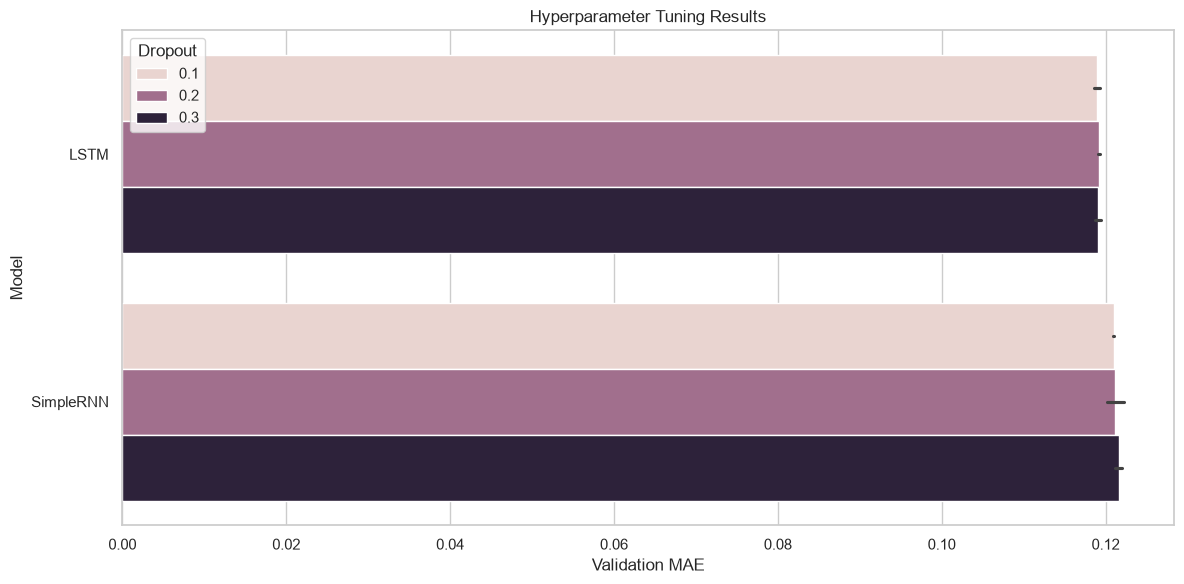

In [28]:
# ============================================================
# 28. Visualize tuning results
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=tuning_table,
    x="Validation MAE",
    y="Model",
    hue="Dropout"
)

plt.title("Hyperparameter Tuning Results")
plt.xlabel("Validation MAE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 14. Final model training

The best configuration identified from the validation set is retrained.

Callbacks:

- **EarlyStopping:** reduces overfitting.
- **ReduceLROnPlateau:** lowers the learning rate when validation performance stops improving.

Huber loss is used because rainfall contains extreme values and Huber loss is less sensitive to large individual errors than ordinary MSE.

In [29]:
# ============================================================
# 29. Final training
# ============================================================

final_models = {}
final_histories = {}
training_results = {}

for model_type, best_config in [
    ("SimpleRNN", best_rnn),
    ("LSTM", best_lstm)
]:

    print(
        f"\nFinal training: {model_type} | "
        f"dropout={best_config['Dropout']} | "
        f"patience={int(best_config['Patience'])}"
    )

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_model(
        model_type,
        float(best_config["Dropout"])
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=int(best_config["Patience"]),
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.time() - start_time

    final_models[model_type] = model
    final_histories[model_type] = history

    training_results[model_type] = {
        "training_time_sec": elapsed,
        "epochs_completed": len(history.history["loss"])
    }

    print(f"Training time: {elapsed:.2f} seconds")


Final training: SimpleRNN | dropout=0.2 | patience=10
Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0239 - mae: 0.1686 - mse: 0.0477 - val_loss: 0.0156 - val_mae: 0.1403 - val_mse: 0.0313 - learning_rate: 0.0010
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0133 - mae: 0.1302 - mse: 0.0265 - val_loss: 0.0136 - val_mae: 0.1321 - val_mse: 0.0273 - learning_rate: 0.0010
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0121 - mae: 0.1224 - mse: 0.0242 - val_loss: 0.0150 - val_mae: 0.1375 - val_mse: 0.0300 - learning_rate: 0.0010
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0114 - mae: 0.1190 - mse: 0.0227 - val_loss: 0.0124 - val_mae: 0.1263 - val_mse: 0.0249 - learning_rate: 0.0010
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0110 - mae: 0.1180 - mse: 0.0220 - val_loss: 0.0140 - val_mae: 0.1335 - val_mse: 0.0280 - learning_rate: 0.0010
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0107 - 

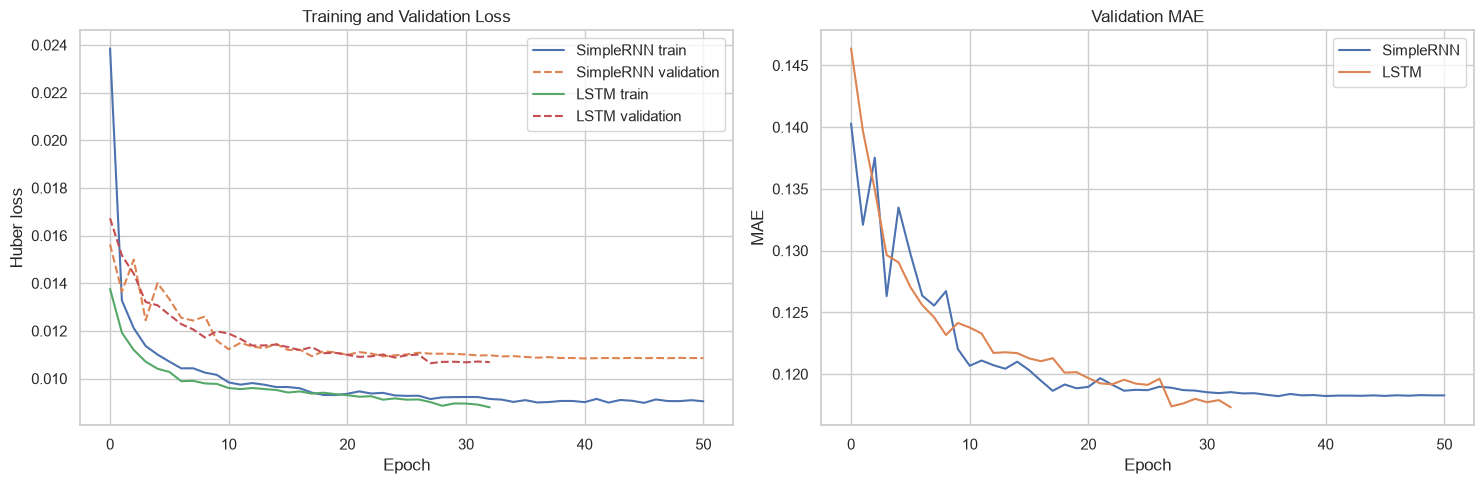

In [30]:
# ============================================================
# 30. Training history comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for model_type in ["SimpleRNN", "LSTM"]:
    history = final_histories[model_type]

    axes[0].plot(
        history.history["loss"],
        label=f"{model_type} train"
    )
    axes[0].plot(
        history.history["val_loss"],
        linestyle="--",
        label=f"{model_type} validation"
    )

    axes[1].plot(
        history.history["val_mae"],
        label=model_type
    )

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber loss")
axes[0].legend()

axes[1].set_title("Validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

## 15. Final evaluation on the unseen test set

All metrics are calculated in the original rainfall unit (**mm**), not in the scaled/log-transformed space.

Metrics:

- **MAE:** average absolute error.
- **RMSE:** penalizes large errors more strongly.
- **R²:** proportion of variance explained by the model.

Lower MAE/RMSE is better. Higher R² is better.

In [31]:
# ============================================================
# 31. Evaluate models and baselines
# ============================================================

def calculate_metrics(y_true, y_pred):
    return {
        "MAE (mm)": mean_absolute_error(y_true, y_pred),
        "RMSE (mm)": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "R²": r2_score(y_true, y_pred)
    }


predictions = {}

evaluation_rows = []

# Neural network models
for model_type in ["SimpleRNN", "LSTM"]:

    y_pred_scaled = (
        final_models[model_type]
        .predict(X_test, verbose=0)
        .ravel()
    )

    y_pred_mm = inverse_target_transform(
        y_pred_scaled
    )

    predictions[model_type] = y_pred_mm

    metrics = calculate_metrics(
        y_test_mm,
        y_pred_mm
    )

    evaluation_rows.append({
        "Model": model_type,
        **metrics,
        "Training time (sec)": training_results[
            model_type
        ]["training_time_sec"]
    })

# Climatology baseline
clim_metrics = calculate_metrics(
    y_test_mm,
    climatology_pred
)

evaluation_rows.append({
    "Model": "Climatology",
    **clim_metrics,
    "Training time (sec)": 0
})

# Persistence baseline
valid_persistence = ~np.isnan(persistence_pred)

persistence_metrics = calculate_metrics(
    y_test_mm[valid_persistence],
    persistence_pred[valid_persistence]
)

evaluation_rows.append({
    "Model": "Persistence",
    **persistence_metrics,
    "Training time (sec)": 0
})

evaluation_df = pd.DataFrame(evaluation_rows)

display(evaluation_df.round(3))

,Model,MAE (mm),RMSE (mm),R²,Training time (sec)
0,SimpleRNN,5.254,12.156,0.123,33.877
1,LSTM,5.153,11.738,0.182,29.670
2,Climatology,7.057,12.983,-0.000,0.000
3,Persistence,6.161,12.883,0.015,0.000


In [32]:
# ============================================================
# 32. Model ranking
# ============================================================

ranking = evaluation_df.sort_values(
    "MAE (mm)"
).reset_index(drop=True)

print("Models ranked by test MAE:")
display(ranking.round(3))

best_model_name = ranking.iloc[0]["Model"]

print(
    f"Best model according to test MAE: {best_model_name}"
)

Models ranked by test MAE:


,Model,MAE (mm),RMSE (mm),R²,Training time (sec)
0,LSTM,5.153,11.738,0.182,29.670
1,SimpleRNN,5.254,12.156,0.123,33.877
2,Persistence,6.161,12.883,0.015,0.000
3,Climatology,7.057,12.983,-0.000,0.000


Best model according to test MAE: LSTM


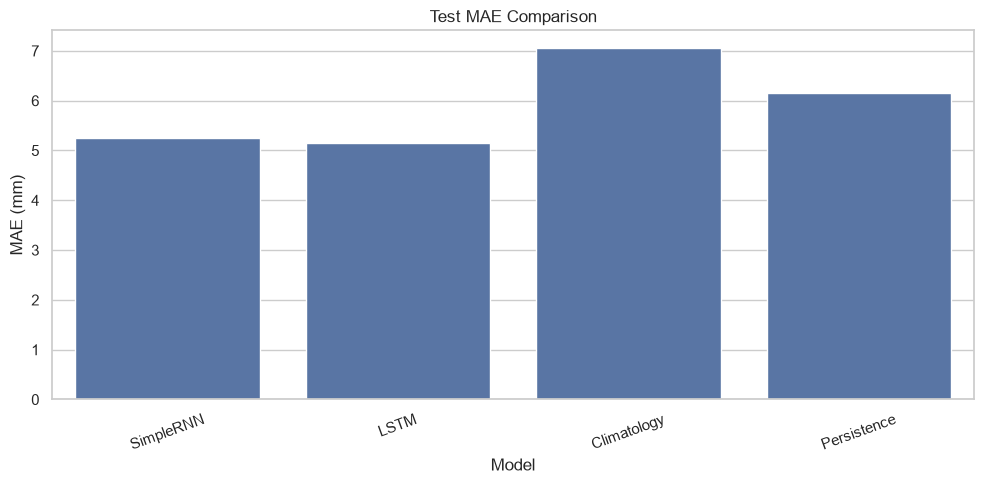

In [33]:
# ============================================================
# 33. Baseline comparison plot
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=evaluation_df,
    x="Model",
    y="MAE (mm)"
)

plt.title("Test MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE (mm)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 16. Actual vs predicted rainfall

The first part of the test period is plotted separately for readability.

This visualization helps determine whether the model captures:

- rainfall timing,
- moderate rainfall,
- and extreme rainfall events.

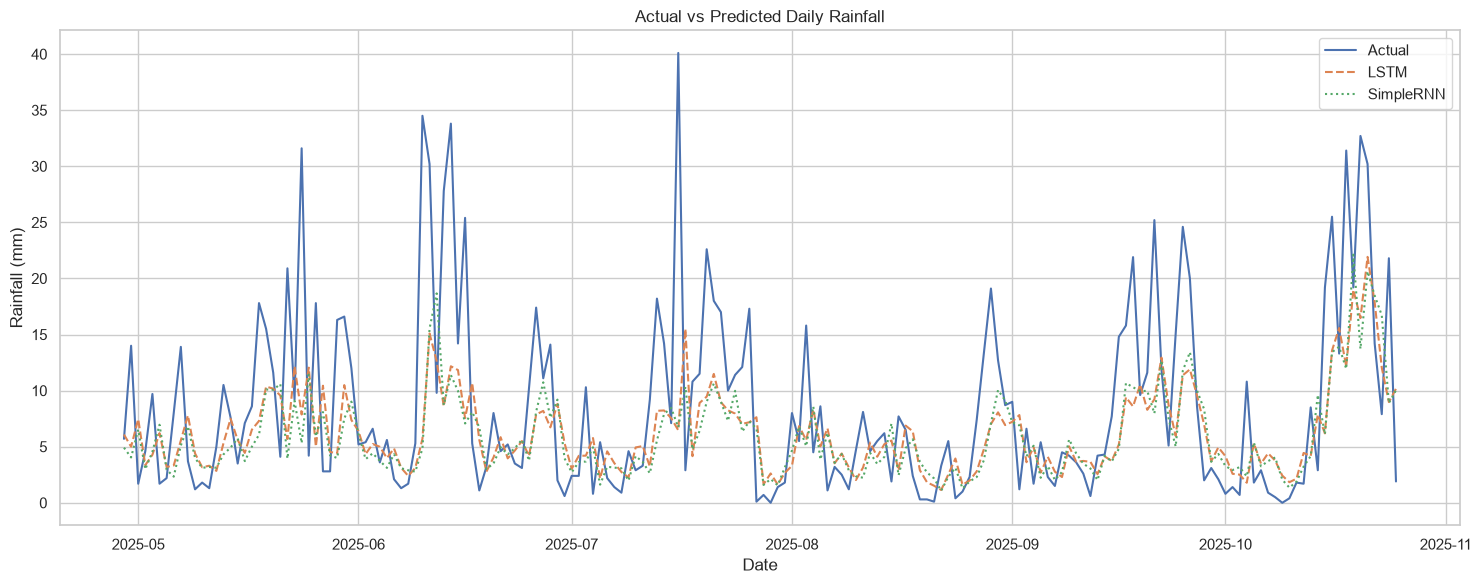

In [34]:
# ============================================================
# 34. Actual vs predicted rainfall
# ============================================================

test_dates = model_data.index[test_positions]

plot_n = min(180, len(test_dates))

plt.figure(figsize=(15, 6))

plt.plot(
    test_dates[:plot_n],
    y_test_mm[:plot_n],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    test_dates[:plot_n],
    predictions["LSTM"][:plot_n],
    label="LSTM",
    linestyle="--"
)

plt.plot(
    test_dates[:plot_n],
    predictions["SimpleRNN"][:plot_n],
    label="SimpleRNN",
    linestyle=":"
)

plt.title("Actual vs Predicted Daily Rainfall")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

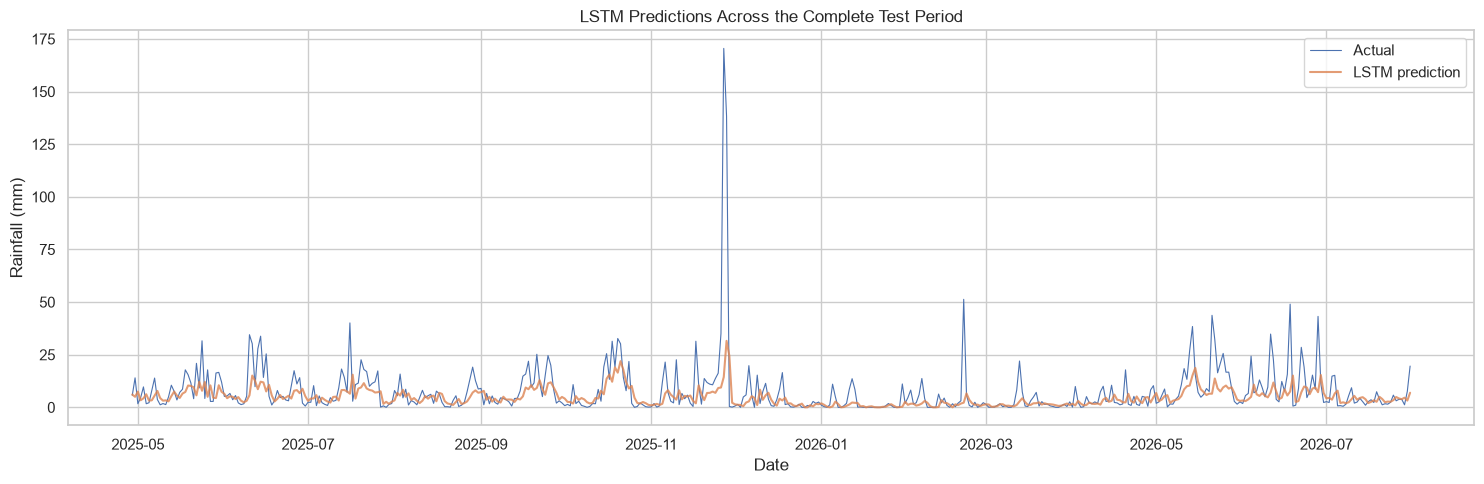

In [35]:
# ============================================================
# 35. Full test-period prediction plot
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    test_dates,
    y_test_mm,
    label="Actual",
    linewidth=0.8
)

plt.plot(
    test_dates,
    predictions["LSTM"],
    label="LSTM prediction",
    alpha=0.8
)

plt.title("LSTM Predictions Across the Complete Test Period")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Residual analysis

For the best neural network model, residuals are calculated as:

**Residual = Actual rainfall − Predicted rainfall**

A good residual pattern should not show strong systematic structure.

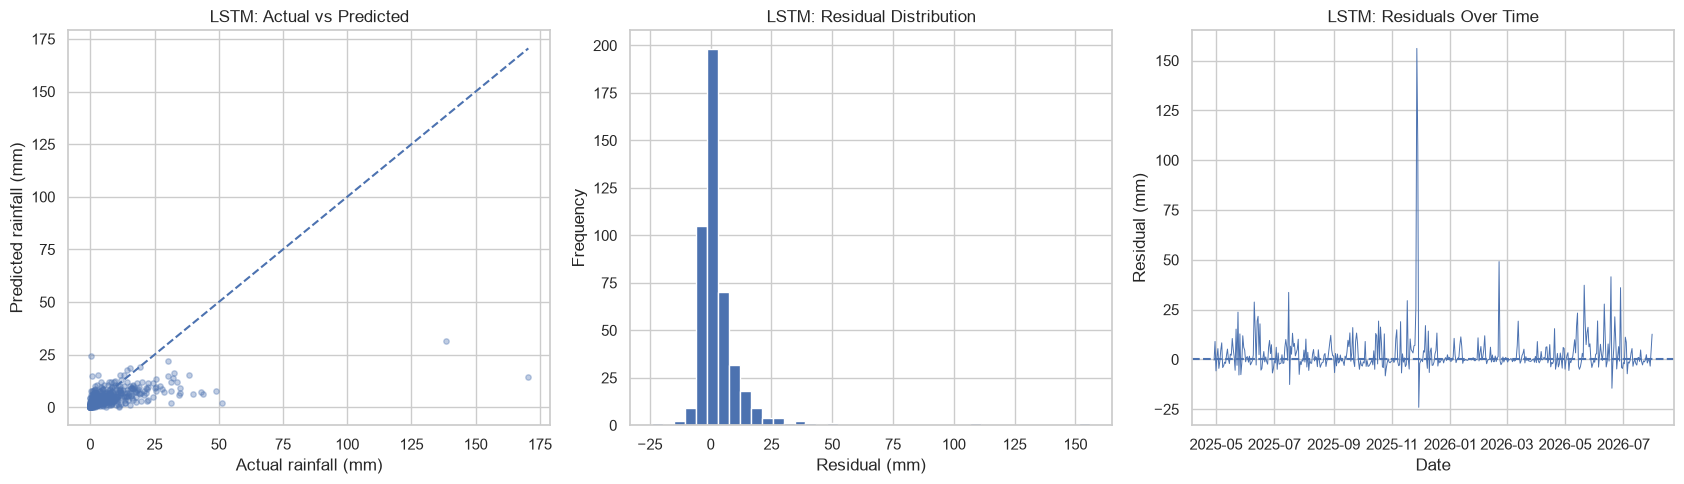

In [36]:
# ============================================================
# 36. Residual analysis
# ============================================================

best_nn = (
    "LSTM"
    if evaluation_df.loc[
        evaluation_df["Model"] == "LSTM",
        "MAE (mm)"
    ].iloc[0]
    <= evaluation_df.loc[
        evaluation_df["Model"] == "SimpleRNN",
        "MAE (mm)"
    ].iloc[0]
    else "SimpleRNN"
)

best_pred = predictions[best_nn]
residuals = y_test_mm - best_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Actual vs predicted
axes[0].scatter(
    y_test_mm,
    best_pred,
    alpha=0.35,
    s=15
)

max_value = max(
    y_test_mm.max(),
    best_pred.max()
)

axes[0].plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

axes[0].set_title(f"{best_nn}: Actual vs Predicted")
axes[0].set_xlabel("Actual rainfall (mm)")
axes[0].set_ylabel("Predicted rainfall (mm)")

# Residual distribution
axes[1].hist(
    residuals,
    bins=40
)

axes[1].set_title(f"{best_nn}: Residual Distribution")
axes[1].set_xlabel("Residual (mm)")
axes[1].set_ylabel("Frequency")

# Residuals over time
axes[2].plot(
    test_dates,
    residuals,
    linewidth=0.7
)

axes[2].axhline(
    0,
    linestyle="--"
)

axes[2].set_title(f"{best_nn}: Residuals Over Time")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Residual (mm)")

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# 37. Ljung-Box test on model residuals
# ============================================================

residual_ljung = acorr_ljungbox(
    residuals,
    lags=[7, 14, 30],
    return_df=True
)

display(residual_ljung)

print(
    "Interpretation: non-significant p-values suggest that "
    "little residual autocorrelation remains at those lags."
)

,lb_stat,lb_pvalue
7,41.913666,5.402837e-07
14,48.009696,1.309717e-05
30,56.968119,2.109922e-03


Interpretation: non-significant p-values suggest that little residual autocorrelation remains at those lags.


## 18. Performance during heavy-rainfall events

Average metrics can hide poor performance on rare extreme events.

Therefore, the best neural network is also evaluated on days where rainfall is above the **90th percentile of the training-period rainfall distribution**.

This is useful because extreme rainfall is often more operationally important than ordinary dry days.

In [38]:
# ============================================================
# 38. Heavy-rainfall evaluation
# ============================================================

heavy_rain_threshold = np.percentile(
    train_target_mm,
    90
)

heavy_mask = y_test_mm >= heavy_rain_threshold

print(
    f"90th percentile training rainfall threshold: "
    f"{heavy_rain_threshold:.2f} mm"
)

print(
    f"Heavy-rainfall test observations: "
    f"{heavy_mask.sum()}"
)

if heavy_mask.sum() > 0:
    heavy_metrics = calculate_metrics(
        y_test_mm[heavy_mask],
        best_pred[heavy_mask]
    )

    display(
        pd.DataFrame([heavy_metrics]).round(3)
    )
else:
    print("No heavy-rainfall observations were found in the test set.")

90th percentile training rainfall threshold: 19.71 mm
Heavy-rainfall test observations: 39


,MAE (mm),RMSE (mm),R²
0,26.323,37.435,-0.682


## 19. Export predictions and model results

The final prediction table is saved so that it can be reused for:

- GitHub documentation
- dashboards
- further analysis
- report figures

In [39]:
# ============================================================
# 39. Create prediction results table
# ============================================================

prediction_results = pd.DataFrame({
    "Date": test_dates,
    "Actual_Rainfall_mm": y_test_mm,
    "SimpleRNN_Predicted_mm": predictions["SimpleRNN"],
    "LSTM_Predicted_mm": predictions["LSTM"],
    "Best_Model": best_nn,
    "Best_Model_Predicted_mm": best_pred,
    "Residual_mm": residuals
})

prediction_results.to_csv(
    "rainfall_test_predictions.csv",
    index=False
)

evaluation_df.to_csv(
    "model_evaluation_results.csv",
    index=False
)

tuning_table.to_csv(
    "hyperparameter_tuning_results.csv",
    index=False
)

print("Saved:")
print("- rainfall_test_predictions.csv")
print("- model_evaluation_results.csv")
print("- hyperparameter_tuning_results.csv")

display(prediction_results.head())

Saved:
- rainfall_test_predictions.csv
- model_evaluation_results.csv
- hyperparameter_tuning_results.csv


,Date,Actual_Rainfall_mm,SimpleRNN_Predicted_mm,LSTM_Predicted_mm,Best_Model,Best_Model_Predicted_mm,Residual_mm
0,2025-04-29,5.7,4.914249,6.082742,LSTM,6.082742,-0.382742
1,2025-04-30,14.0,4.041538,4.996732,LSTM,4.996732,9.003268
2,2025-05-01,1.7,6.516190,7.460139,LSTM,7.460139,-5.760139
3,2025-05-02,4.6,2.991251,3.361071,LSTM,3.361071,1.238929
4,2025-05-03,9.7,4.552478,4.279436,LSTM,4.279436,5.420564


In [40]:
# ============================================================
# 40. Save trained models and scaler
# ============================================================

final_models["SimpleRNN"].save(
    "weather_simplernn.keras"
)

final_models["LSTM"].save(
    "weather_lstm.keras"
)

with open("weather_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved:")
print("- weather_simplernn.keras")
print("- weather_lstm.keras")
print("- weather_scaler.pkl")

Saved:
- weather_simplernn.keras
- weather_lstm.keras
- weather_scaler.pkl


## 20. Results and discussion

### What this analysis demonstrates

The project provides a complete forecasting workflow rather than only training a neural network:

1. The hourly data was validated and converted to daily observations.
2. Rainfall showed strong skewness and potential extreme events, so extreme rainfall was investigated rather than automatically removed.
3. Seasonal and temporal patterns were explored.
4. ADF, ACF, PACF and Ljung-Box diagnostics were used to understand temporal dependence.
5. Lagged and rolling rainfall features were created without target leakage.
6. The data was split chronologically.
7. Scaling was fitted only on the training period.
8. SimpleRNN and LSTM architectures were compared.
9. Hyperparameters were selected using validation performance.
10. Final performance was measured on an unseen test period.
11. Simple baselines were included to establish whether deep learning provides meaningful improvement.
12. Residual and heavy-rainfall analyses were performed.

### How to report the result

Do not claim that the model is "perfect" or that LSTM is universally better.

Instead, report the actual test results generated by the notebook and discuss:

- MAE
- RMSE
- R²
- performance relative to the baselines
- behaviour during heavy rainfall
- residual autocorrelation
- limitations of using historical meteorological observations

### Important limitation

This is a **one-day-ahead forecasting model**.

It should not be described as a reliable 14-day weather forecasting system because future temperature, humidity, wind and pressure values would not be known in a real deployment. A genuine multi-day operational forecast would require future meteorological forecasts or a multi-step forecasting framework.

## 21. Reproducibility and project structure

Recommended GitHub repository structure:

```text
weather-forecasting/
│
├── weather_forecasting_professional_github.ipynb
├── weather_raw.xlsx
├── rainfall_test_predictions.csv
├── model_evaluation_results.csv
├── hyperparameter_tuning_results.csv
├── weather_lstm.keras
├── weather_simplernn.keras
├── weather_scaler.pkl
└── README.md
```

### Recommended GitHub README sections

- Project overview
- Problem statement
- Dataset
- Methodology
- Exploratory data analysis
- Feature engineering
- Model architectures
- Hyperparameter tuning
- Evaluation metrics
- Results
- Limitations
- Future improvements

This structure makes the project much stronger for a **Data Science / Machine Learning portfolio** because it demonstrates the complete workflow from raw data to model evaluation and reproducibility.

## Final takeaway

The strongest part of this project is not simply using LSTM.

The value comes from demonstrating a **proper time-series machine-learning workflow**:

**Raw hourly weather data → data validation → daily aggregation → EDA → statistical diagnostics → leakage-safe feature engineering → chronological validation → hyperparameter tuning → recurrent neural networks → baseline comparison → residual diagnostics → final evaluation → reproducible outputs.**

That is the level of workflow expected from a serious undergraduate Data Science project.